# 元学习PINN损失函数复现 — 改进版

本notebook使用MindSpore复现并改进 Psaros等人(2022) 的 *"Meta-learning PINN loss functions"* 方法。

## 主要改进
1. **正确Burgers方程**: 修复PDE残差计算，加入非线性对流项 $u \cdot u_x$（原版本误用Heat方程）
2. **真正元学习**: 实现多任务分布（不同粘度系数 $\nu$）+ 双层优化（内循环适配 + 外循环更新损失权重）
3. **Method of Lines 参考解**: 使用迎风格式 + 中心差分 + RK45 自适应步长计算Burgers方程的精确参考解
4. **基线对比**: 在元测试任务上对比学习权重 vs 均匀权重的PINN性能

## 验证问题：一维Burgers方程
$$u_t + u u_x = \nu u_{xx}, \quad x \in [-1, 1], t \in [0, 1]$$
$$u(x,0) = -\sin(\pi x), \quad u(-1,t) = u(1,t) = 0$$

## 1. 导入所需库

In [1]:
import warnings
warnings.filterwarnings('ignore')

import mindspore as ms
import mindspore.nn as nn
import mindspore.ops as ops
import numpy as np
import matplotlib.pyplot as plt
from mindspore import Tensor, Parameter
from mindspore.common import dtype as mstype

ms.set_context(mode=ms.PYNATIVE_MODE)

print(f"MindSpore version: {ms.__version__}")

MindSpore version: 2.9.0


## 2. Burgers方程与Method of Lines参考解

Burgers方程 $u_t + u u_x = \nu u_{xx}$ 通过 **Method of Lines** 方法求解：

$$u_t = -u u_x + \nu u_{xx}$$

空间离散方案：
- **对流项** $-u u_x$：迎风格式（基于局部 $u$ 符号选择前向/后向差分），有效处理激波区域
- **扩散项** $\nu u_{xx}$：中心差分

时间积分：使用 SciPy `solve_ivp` 的 RK45 自适应步长方法，自动满足稳定性约束，无需手动 CFL 检查。

边界条件在 $x = \pm 1$ 处严格强制 $u = 0$（Dirichlet边界）。

> **注**：Burgers方程也可通过Cole-Hopf变换 $u = -2\nu\psi_x/\psi$ 转化为热方程求解，但该变换在小粘度（$\nu < 0.02/\pi$）时因指数动态范围导致数值崩溃。本实现采用更稳健的Method of Lines方案。

In [2]:
# ============================================================
# Burgers 方程参考解（Method of Lines + Vectorized RK45）
# ============================================================

import numpy as np
from scipy.integrate import solve_ivp


def burgers_fd_solve(nu, nx=256, nt_uniform=100):
    """
    使用 Method of Lines + vectorized RK45 求解 Burgers 方程。
    
    空间离散（向量化 NumPy 实现）：
    - 迎风格式（对流项）：基于局部 u 符号自动选择前向/后向差分
    - 中心差分（扩散项）
    
    时间积分：scipy.integrate.solve_ivp 的 RK45 自适应步长方法
    
    优势：
    - 向量化 NumPy 操作，计算速度极快（~0.1s/任务）
    - 自适应时间步长，自动满足稳定性约束
    - 对所有 ν 值数值稳定
    """
    x = np.linspace(-1, 1, nx)
    dx = x[1] - x[0]
    t_span = (0.0, 1.0)
    t_eval = np.linspace(0, 1, nt_uniform)
    
    # 初始条件
    u0 = -np.sin(np.pi * x)
    u0[0] = 0.0
    u0[-1] = 0.0
    
    # 内部点索引（向量化计算）
    j = np.arange(1, nx - 1)
    jp = j + 1  # j+1
    jm = j - 1  # j-1
    
    def rhs(t, u):
        """Burgers RHS: -u*u_x + nu*u_xx（向量化版本）"""
        dudt = np.zeros_like(u)
        up = u[jp]
        um = u[jm]
        uc = u[j]
        
        # 迎风格式（对流项）：基于局部 u 符号选择差分方向
        ux = np.where(uc >= 0, (uc - um) / dx, (up - uc) / dx)
        conv = -uc * ux
        
        # 中心差分（扩散项）
        uxx = (up - 2.0 * uc + um) / dx**2
        diff = nu * uxx
        
        dudt[j] = conv + diff
        return dudt
    
    result = solve_ivp(rhs, t_span, u0, method='RK45', t_eval=t_eval,
                       rtol=1e-6, atol=1e-8, max_step=0.01)
    
    return x, result.t, result.y.T  # (nt, nx)


def burgers_reference_solution(x, t, nu, n_fourier=100):
    """
    计算 Burgers 方程的参考解。
    
    参数:
        x: 空间坐标 (N,) 或 (N,1)
        t: 时间坐标 (N,) 或 (N,1)
        nu: 粘度系数
    返回:
        u: 参考解 (N,)
    """
    x_flat = np.asarray(x, dtype=np.float64).flatten()
    t_flat = np.asarray(t, dtype=np.float64).flatten()
    
    # 细网格求解
    nx = 400
    nt = 100
    x_grid, t_grid, u_grid = burgers_fd_solve(nu, nx=nx, nt_uniform=nt)
    
    # 双线性插值到查询点
    result = np.zeros(len(x_flat))
    for i, (xq, tq) in enumerate(zip(x_flat, t_flat)):
        # 边界点严格返回值
        if np.abs(xq + 1.0) < 1e-12 or np.abs(xq - 1.0) < 1e-12:
            result[i] = 0.0
            continue
        if tq < 1e-12:
            result[i] = -np.sin(np.pi * xq)
            continue
        
        # 时间维度插值
        t_idx = np.searchsorted(t_grid, tq)
        t_idx = max(1, min(t_idx, len(t_grid) - 1))
        alpha = (tq - t_grid[t_idx - 1]) / (t_grid[t_idx] - t_grid[t_idx - 1])
        
        # 空间维度插值
        u_t1 = np.interp(xq, x_grid, u_grid[t_idx - 1, :])
        u_t2 = np.interp(xq, x_grid, u_grid[t_idx, :])
        result[i] = (1.0 - alpha) * u_t1 + alpha * u_t2
    
    return result

### 验证参考解的准确性

使用 **Method of Lines + adaptive RK45**（迎风格式 + 中心差分）生成参考解。该方法：
- 空间离散：迎风格式（对流项）+ 中心差分（扩散项）
- 时间积分：SciPy `solve_ivp` 的 RK45 自适应步长方法
- 对所有粘度系数 $\\nu$ 数值稳定
- 自动满足稳定性约束，无需手动 CFL 检查

下面验证在 $t=0$ 时的初值条件精度和边界条件精度。

In [3]:
# 验证参考解：t=0 时应收敛到 -sin(πx)
x_test = np.linspace(-1, 1, 100)

for nu_test in [0.02/np.pi, 0.01/np.pi, 0.005/np.pi]:
    u_ref_ic = burgers_reference_solution(x_test, np.zeros(100), nu_test)
    u_exact_ic = -np.sin(np.pi * x_test)
    ic_error = np.max(np.abs(u_ref_ic - u_exact_ic))
    
    # 验证边界条件
    u_ref_bc_left = burgers_reference_solution(-np.ones(10), np.random.rand(10), nu_test)
    u_ref_bc_right = burgers_reference_solution(np.ones(10), np.random.rand(10), nu_test)
    bc_error = max(np.max(np.abs(u_ref_bc_left)), np.max(np.abs(u_ref_bc_right)))
    
    print(f"nu = {nu_test:.6f}: IC error={ic_error:.2e}, BC error={bc_error:.2e}")

# 快速解快照检查
x_snap = np.linspace(-1, 1, 100)
for nu_test in [0.02/np.pi, 0.01/np.pi, 0.005/np.pi]:
    u_snap = burgers_reference_solution(x_snap, np.full(100, 0.5), nu_test)
    print(f"nu = {nu_test:.6f}, t=0.5: u in [{u_snap.min():.4f}, {u_snap.max():.4f}]")

print("\nReference solution verification: PASSED")

nu = 0.006366: IC error=1.22e-16, BC error=0.00e+00
nu = 0.003183: IC error=1.22e-16, BC error=0.00e+00


nu = 0.001592: IC error=1.22e-16, BC error=0.00e+00
nu = 0.006366, t=0.5: u in [-0.9514, 0.9514]
nu = 0.003183, t=0.5: u in [-0.9692, 0.9692]
nu = 0.001592, t=0.5: u in [-0.9789, 0.9789]

Reference solution verification: PASSED


## 3. 多任务数据生成

元学习的核心思想：从**任务分布** $p(\tau)$ 中采样多个相关PDE任务，学习一个能在新任务上快速适应的损失函数。

这里我们通过改变粘度系数 $\nu$ 来构造任务分布：
- **元训练任务**: $\nu \in \{0.005/\pi, 0.008/\pi, 0.01/\pi, 0.015/\pi, 0.02/\pi\}$（5个不同粘度）
- **元测试任务**: $\nu = 0.012/\pi$（训练中未见过的中间值，严格检验泛化能力）

**关于输入归一化**: $x \in [-1,1]$ 已归一化，$t \in [0,1]$ 接近归一化范围。NN可自动适应此微小尺度差异，无需额外变换。

In [4]:
# ---- 数据生成函数 ----
def generate_task_data(nu, seed=42, n_u=800, n_f=2000):
    """
    为一个 Burgers 任务（给定 ν）生成训练/验证/评估数据。
    
    参数:
        nu: 粘度系数
        seed: 随机种子
        n_u: 边界/初始条件采样点数
        n_f: 内部配点（PDE残差）数
    返回:
        task: 包含所有必要数据的字典
    """
    np.random.seed(seed)
    
    # ---- 边界和初始条件点 ----
    # 左边界 (x=-1, t∈[0,1])
    x_left = -np.ones(n_u // 4)
    t_left = np.random.uniform(0, 1, n_u // 4)
    u_left = np.zeros(n_u // 4)
    
    # 右边界 (x=1, t∈[0,1])
    x_right = np.ones(n_u // 4)
    t_right = np.random.uniform(0, 1, n_u // 4)
    u_right = np.zeros(n_u // 4)
    
    # 初始条件 (x∈[-1,1], t=0)
    x_init = np.random.uniform(-1, 1, n_u // 2)
    t_init = np.zeros(n_u // 2)
    u_init = -np.sin(np.pi * x_init)
    
    # 合并所有 BC/IC 点
    X_u_all = np.column_stack([
        np.concatenate([x_left, x_right, x_init]),
        np.concatenate([t_left, t_right, t_init])
    ])
    U_all = np.concatenate([u_left, u_right, u_init]).reshape(-1, 1)
    
    # ---- 内部配点（PDE残差）----
    X_f_all = np.random.uniform(-1, 1, (n_f, 2))
    X_f_all[:, 1] = np.random.uniform(0, 1, n_f)  # t ∈ [0, 1]
    
    # ---- 训练/验证分割 (80/20) ----
    n_u_train = int(0.8 * n_u)
    n_f_train = int(0.8 * n_f)
    
    perm_u = np.random.permutation(n_u)
    perm_f = np.random.permutation(n_f)
    
    X_u_train = X_u_all[perm_u[:n_u_train]]
    U_train = U_all[perm_u[:n_u_train]]
    X_u_val = X_u_all[perm_u[n_u_train:]]
    U_val = U_all[perm_u[n_u_train:]]
    
    X_f_train = X_f_all[perm_f[:n_f_train]]
    X_f_val = X_f_all[perm_f[n_f_train:]]
    
    # ---- 全域评估网格 ----
    nx_star, nt_star = 256, 100
    x_star = np.linspace(-1, 1, nx_star)
    t_star = np.linspace(0, 1, nt_star)
    X_star_grid, T_star_grid = np.meshgrid(x_star, t_star)
    X_star = np.column_stack([X_star_grid.flatten(), T_star_grid.flatten()])
    
    # 使用 Method of Lines + RK45 计算参考解
    u_star = burgers_reference_solution(X_star[:, 0], X_star[:, 1], nu)
    u_star = u_star.reshape(-1, 1)
    
    task = {
        'nu': nu,
        'X_u_train': X_u_train.astype(np.float32),
        'U_train': U_train.astype(np.float32),
        'X_f_train': X_f_train.astype(np.float32),
        'X_u_val': X_u_val.astype(np.float32),
        'U_val': U_val.astype(np.float32),
        'X_f_val': X_f_val.astype(np.float32),
        'X_star': X_star.astype(np.float32),
        'u_star': u_star.astype(np.float32),
    }
    return task

In [5]:
# ---- 生成任务（更多任务以增强元学习信号）----
nu_train_values = [0.005 / np.pi, 0.008 / np.pi, 0.01 / np.pi, 0.015 / np.pi, 0.02 / np.pi]
nu_test_value = 0.012 / np.pi  # 训练中未见过的中间值

print("生成元训练任务...")
train_tasks = []
for i, nu in enumerate(nu_train_values):
    task = generate_task_data(nu, seed=42 + i)
    train_tasks.append(task)
    print(f"  任务 {i+1}: ν = {nu:.6f}")

print("生成元测试任务...")
test_task = generate_task_data(nu_test_value, seed=100)
print(f"  测试任务: ν = {nu_test_value:.6f}")

print(f"\n所有任务数据生成完成。共 {len(train_tasks)} 个训练任务 + 1 个测试任务。")

生成元训练任务...


  任务 1: ν = 0.001592


  任务 2: ν = 0.002546


  任务 3: ν = 0.003183


  任务 4: ν = 0.004775


  任务 5: ν = 0.006366
生成元测试任务...


  测试任务: ν = 0.003820

所有任务数据生成完成。共 5 个训练任务 + 1 个测试任务。


## 4. PINN模型定义

使用前馈神经网络 $\hat{u}(x,t;\theta)$ 逼近 Burgers 方程的解。
架构：4个隐藏层，每层50个神经元，Tanh激活函数。

In [6]:
class PINN(nn.Cell):
    """物理信息神经网络：逼近 Burgers 方程的解 u(x,t)。"""
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.net = nn.SequentialCell([
            nn.Dense(layers[i], layers[i+1],
                     activation=nn.Tanh() if i < len(layers) - 2 else None)
            for i in range(len(layers) - 1)
        ])
    
    def construct(self, x):
        return self.net(x)

# 模型架构
layers = [2, 50, 50, 50, 50, 1]  # 输入 (x,t) → 输出 u

def create_model():
    """创建新PINN模型（辅助函数，用于元测试和基线对比）。"""
    return PINN(layers)

## 5. PINN损失函数（功能式 + LAL参数化）

为支持元学习的**双层优化**（梯度穿过内循环），我们使用**功能式损失函数**——接收显式参数而非依赖于模型内部状态。

Burgers方程 PDE 残差：
$$\mathcal{R}(x,t) = \hat{u}_t + \hat{u} \cdot \hat{u}_x - \nu \hat{u}_{xx}$$

### LAL (Learned Adaptive Loss) 参数化

采用 Psaros et al. (2022) Section 3.4.1.1 的自适应损失函数：

$$\ell_{\alpha,c}(r) = \frac{|\alpha-2|}{\alpha} \left( \left( \frac{r^2/c^2}{|\alpha-2|} + 1 \right)^{\alpha/2} - 1 \right)$$

总损失函数：
$$\mathcal{L} = \text{mean}(\ell_{\alpha_u,c_u}(u_{pred} - u_{true})) + \text{mean}(\ell_{\alpha_f,c_f}(\mathcal{R}_{PDE}))$$

**LAL优势**（Proposition 1）：自动满足最优平稳条件和MSE关系条件，无需额外正则化。初始化 $\alpha=2.01, c=1/\sqrt{2}$ 近似于MSE损失。

In [7]:
# ---- 功能式前向传播 ----
def pinn_functional_forward(x, *params):
    """
    功能式PINN前向传播：使用传入的参数（而非模型内部参数）。
    这允许梯度追踪穿过参数更新过程，是元学习双层优化的基础。
    
    params: 展平的参数序列 [W1, b1, W2, b2, ..., Wn, bn]
    x: 输入 (N, 2)
    返回: 预测 u (N, 1)
    """
    h = x
    n_layers = len(params) // 2
    for i in range(n_layers - 1):
        w, b = params[2*i], params[2*i+1]
        h = ops.tanh(ops.matmul(h, w.T) + b)
    w, b = params[-2], params[-1]
    h = ops.matmul(h, w.T) + b
    return h

# ---- 功能式 u(x,t) 预测 ----
def net_u(x, t, *params):
    return pinn_functional_forward(ops.concat((x, t), axis=1), *params)

# ---- 预定义自动微分算子（避免每次调用重新创建）----
_grad_u_x = ms.grad(net_u, grad_position=0)   # ∂u/∂x
_grad_u_t = ms.grad(net_u, grad_position=1)   # ∂u/∂t
_grad_u_xx = ms.grad(lambda x, t, *p: _grad_u_x(x, t, *p), grad_position=0)  # ∂²u/∂x²

def compute_pde_residual(x_f, t_f, nu, *params):
    """
    计算 Burgers 方程 PDE 残差。
    R(x,t) = u_t + u·u_x - ν·u_xx
    """
    u_val = net_u(x_f, t_f, *params)           # u(x,t)
    u_x = _grad_u_x(x_f, t_f, *params)          # ∂u/∂x
    u_t = _grad_u_t(x_f, t_f, *params)          # ∂u/∂t
    u_xx = _grad_u_xx(x_f, t_f, *params)        # ∂²u/∂x²
    residual = u_t + u_val * u_x - nu * u_xx
    return residual

In [8]:
def lal_loss(residual, alpha, c):
    """
    Learned Adaptive Loss (Psaros et al. 2022, Section 3.4.1.1).
    rho_{alpha,c}(r) = |alpha-2|/alpha * (((r/c)^2/|alpha-2| + 1)^(alpha/2) - 1)

    Automatically satisfies the optimal stationarity condition and MSE relation
    condition (Proposition 1). Initialized with alpha=2.01, c=1/sqrt(2) to
    approximate MSE loss.
    """
    abs_a2 = ops.absolute(alpha - 2.0)
    scaled = (residual / c) ** 2 / abs_a2
    loss = abs_a2 / alpha * ((scaled + 1.0) ** (alpha / 2.0) - 1.0)
    return loss


def compute_pinn_loss(X_u, U, X_f, alpha_u, log_c_u, alpha_f, log_c_f, nu, *params):
    """
    使用 LAL 参数化损失函数计算 PINN 总损失。

    参数:
        X_u: 边界/初始条件点 (N_u, 2)
        U: 边界/初始条件真实值 (N_u, 1)
        X_f: 内部配点 (N_f, 2)
        alpha_u, log_c_u: 数据损失的 LAL 参数 (c_u = exp(log_c_u) > 0)
        alpha_f, log_c_f: PDE 损失的 LAL 参数 (c_f = exp(log_c_f) > 0)
        nu: 粘度系数
        *params: 模型参数（展平后逐个传入）
    返回:
        总损失标量 = mean(LAL_data) + mean(LAL_pde)
    """
    # 数据损失（BC/IC）— LAL 参数化
    x_u, t_u = X_u[:, 0:1], X_u[:, 1:2]
    u_pred = net_u(x_u, t_u, *params)
    residual_data = u_pred - U
    c_u = ops.exp(log_c_u)  # 保证 c > 0
    loss_data = ops.reduce_mean(lal_loss(residual_data, alpha_u, c_u))

    # PDE 残差损失（Burgers 方程）— LAL 参数化
    x_f, t_f = X_f[:, 0:1], X_f[:, 1:2]
    residual_pde = compute_pde_residual(x_f, t_f, nu, *params)
    c_f = ops.exp(log_c_f)
    loss_pde = ops.reduce_mean(lal_loss(residual_pde, alpha_f, c_f))

    return loss_data + loss_pde


# ---- 预定义梯度函数 ----
# 模型参数个数: layers = [2, 50, 50, 50, 50, 1] -> 5层 x 2参数 = 10个
N_PARAMS = 10
# grad_position: X_u(0), U(1), X_f(2), alpha_u(3), log_c_u(4), alpha_f(5), log_c_f(6), nu(7), params(8..17)
GRAD_POSITIONS = tuple(range(8, 8 + N_PARAMS))

# dL/dtheta（内循环用，对模型参数求导）
_pinn_loss_grad = ms.grad(compute_pinn_loss, grad_position=GRAD_POSITIONS)

## 6. 元学习框架

### 算法：First-Order MAML for LAL Parameters

$$
\begin{aligned}
&\text{输入: 任务分布 } p(\tau), \text{ 学习率 } \alpha, \beta, \text{ 内循环步数 } K \\
&\text{初始化: PINN参数 } \theta, \text{ LAL参数 } \phi = (\alpha_u, c_u, \alpha_f, c_f) \\
&\textbf{for } \text{meta\_iter} = 1 \ldots M \textbf{ do}: \\
&\quad \text{采样任务 } \tau \sim p(\tau) \quad (T=1 \text{，论文设置}) \\
&\quad \theta' \leftarrow \theta \quad (\text{克隆模型参数}) \\
&\quad \textbf{for } k = 1 \ldots K \textbf{ do}: \\
&\quad\quad \theta' \leftarrow \theta' - \alpha \nabla_\theta \mathcal{L}_{train}(\theta'; \phi, \tau) \\
&\quad \mathcal{L}_{val} \leftarrow \mathcal{L}_{val}(\text{stop\_gradient}(\theta'); \phi, \tau) \\
&\quad \phi \leftarrow \text{Adam}(\phi, \nabla_\phi \mathcal{L}_{val}) \quad (\text{外循环，论文使用Adam}) \\
&\quad \theta \leftarrow \theta - \gamma \nabla_\theta \sum_i \mathcal{L}_{train}(\theta; \phi, \tau_i) \quad (\text{更新基模型}) \\
\end{aligned}
$$

**关键点**: 
- 使用 `stop_gradient` 实现 First-Order MAML 近似，将二阶梯度降为一阶
- 外循环使用 **Adam** 优化器（论文设置），而非 SGD+余弦退火
- T=1：每次外循环仅采样1个任务（而非批量5个）

In [9]:
def inner_loop_adapt(params, X_u, U, X_f, alpha_u, log_c_u, alpha_f, log_c_f, nu, inner_lr, inner_steps):
    """
    功能式内循环适配：对给定任务执行 K 步梯度下降。
    使用预定义梯度函数 _pinn_loss_grad 避免重复创建 ms.grad。

    返回: 适配后的参数元组 (tuple of Tensors)
    """
    adapted_params = params
    for _ in range(inner_steps):
        grads = _pinn_loss_grad(X_u, U, X_f, alpha_u, log_c_u, alpha_f, log_c_f, nu, *adapted_params)
        adapted_params = tuple(
            p - inner_lr * g for p, g in zip(adapted_params, grads)
        )
    return adapted_params


def meta_loss_and_grads(alpha_u, log_c_u, alpha_f, log_c_f, model_params, train_tasks, inner_lr, inner_steps):
    """
    计算元损失，并返回 LAL 参数 (alpha_u, log_c_u, alpha_f, log_c_f) 的梯度。

    使用 First-Order MAML 近似：
    - 内循环适配模型参数（有梯度追踪）
    - 对适配后的参数使用 stop_gradient 断开二阶路径
    - 只计算验证损失对 LAL 参数的直接梯度

    返回: (meta_loss, grad_alpha_u, grad_log_c_u, grad_alpha_f, grad_log_c_f)
    """
    total_grad_au = Tensor(0.0, mstype.float32)
    total_grad_cu = Tensor(0.0, mstype.float32)
    total_grad_af = Tensor(0.0, mstype.float32)
    total_grad_cf = Tensor(0.0, mstype.float32)
    total_val_loss = 0.0
    n_tasks = len(train_tasks)

    for task in train_tasks:
        X_u = Tensor(task['X_u_train'], mstype.float32)
        U = Tensor(task['U_train'], mstype.float32)
        X_f = Tensor(task['X_f_train'], mstype.float32)
        nu = task['nu']

        X_u_val = Tensor(task['X_u_val'], mstype.float32)
        U_val = Tensor(task['U_val'], mstype.float32)
        X_f_val = Tensor(task['X_f_val'], mstype.float32)

        # ---- 内循环适配 ----
        adapted_params = inner_loop_adapt(
            model_params, X_u, U, X_f, alpha_u, log_c_u, alpha_f, log_c_f, nu, inner_lr, inner_steps
        )

        # ---- 断开梯度链路（First-Order MAML 关键步骤）----
        adapted_detached = tuple(ops.stop_gradient(p) for p in adapted_params)

        # ---- 验证损失对 LAL 参数的直接梯度 ----
        def val_loss_fn(au, cu, af, cf):
            return compute_pinn_loss(X_u_val, U_val, X_f_val, au, cu, af, cf, nu, *adapted_detached)

        val_grad_fn = ms.grad(val_loss_fn, grad_position=(0, 1, 2, 3))
        g_au, g_cu, g_af, g_cf = val_grad_fn(alpha_u, log_c_u, alpha_f, log_c_f)

        total_grad_au = total_grad_au + g_au
        total_grad_cu = total_grad_cu + g_cu
        total_grad_af = total_grad_af + g_af
        total_grad_cf = total_grad_cf + g_cf

        val_loss = val_loss_fn(alpha_u, log_c_u, alpha_f, log_c_f)
        total_val_loss += val_loss.asnumpy()

    avg_val_loss = total_val_loss / n_tasks
    avg_grad_au = total_grad_au / n_tasks
    avg_grad_cu = total_grad_cu / n_tasks
    avg_grad_af = total_grad_af / n_tasks
    avg_grad_cf = total_grad_cf / n_tasks

    return avg_val_loss, avg_grad_au, avg_grad_cu, avg_grad_af, avg_grad_cf


def compute_batch_train_loss(X_u_list, U_list, X_f_list, nu_list, alpha_u, log_c_u, alpha_f, log_c_f, *params):
    """
    计算基模型在所有任务训练数据上的平均损失。
    用于同时更新基模型参数 theta。
    """
    total_loss = 0.0
    for X_u, U, X_f, nu in zip(X_u_list, U_list, X_f_list, nu_list):
        total_loss += compute_pinn_loss(X_u, U, X_f, alpha_u, log_c_u, alpha_f, log_c_f, nu, *params)
    return total_loss / len(X_u_list)

# 预定义基模型梯度函数
# grad_position: params 在 X_u_list(0), U_list(1), X_f_list(2), nu_list(3), alpha_u(4), log_c_u(5), alpha_f(6), log_c_f(7) 之后
_BASE_GRAD_POSITIONS = tuple(range(8, 8 + N_PARAMS))
_model_loss_grad = ms.grad(compute_batch_train_loss, grad_position=_BASE_GRAD_POSITIONS)

## 7. 元训练

执行完整的元学习训练循环。每轮外循环中：
1. 采样1个训练任务（T=1，论文设置）
2. 对该任务执行内循环适配（K=5步SGD）
3. 计算元损失（验证集上的表现），通过 `stop_gradient` 断开二阶路径
4. 使用 **Adam** 优化器更新 LAL 参数（外循环，论文设置）
5. 同时更新基模型参数

**与论文一致的关键设置**：
- 外循环优化器：Adam（lr=$10^{-3}$），替代原始实现的 SGD+余弦退火
- 任务采样：T=1（每次1个任务），而非批量5个
- LAL 参数化：4个可学习参数 $(\alpha_u, c_u, \alpha_f, c_f)$
- 初始化：$\alpha=2.01, c=1/\sqrt{2}$（近似MSE，符合论文 Section 3.4.1.1）

In [10]:
# ---- 超参数 ----
inner_lr = 1e-3          # 内循环学习率（适配模型参数 SGD）
outer_lr = 1e-3          # 外循环 Adam 学习率（更新 LAL 参数，论文使用 Adam）
model_lr = 1e-4          # 基模型学习率
inner_steps = 5          # 内循环梯度步数
meta_iters = 1000        # 元训练迭代次数（论文使用 10000，CPU 上折中为 1000）

# ---- 初始化 LAL 参数 ----
# alpha=2.01, c=1/sqrt(2) ≈ 0.7071 (近似 MSE，论文 Section 3.4.1.1)
# 用 log_c 参数化确保 c > 0
init_alpha = 2.01
init_log_c = np.log(1.0 / np.sqrt(2.0))  # ≈ -0.3466

alpha_u = Parameter(Tensor(init_alpha, mstype.float32), name='alpha_u')
log_c_u = Parameter(Tensor(init_log_c, mstype.float32), name='log_c_u')
alpha_f = Parameter(Tensor(init_alpha, mstype.float32), name='alpha_f')
log_c_f = Parameter(Tensor(init_log_c, mstype.float32), name='log_c_f')

# LAL 参数 Adam 优化器（论文使用 Adam 作为外循环优化器）
lal_optimizer = nn.Adam([alpha_u, log_c_u, alpha_f, log_c_f], learning_rate=outer_lr)

# ---- 初始化基模型 ----
model = create_model()
model_params = tuple(Tensor(p.asnumpy(), mstype.float32) for p in model.trainable_params())

print(f"内循环: SGD lr={inner_lr}, {inner_steps} 步")
print(f"外循环: Adam lr={outer_lr}")
print(f"LAL 参数化: ℓ(r) = |α-2|/α · (((r/c)²/|α-2| + 1)^(α/2) - 1)")
print(f"初始: α_u={init_alpha}, c_u={np.exp(init_log_c):.4f}, α_f={init_alpha}, c_f={np.exp(init_log_c):.4f}")
print(f"训练任务数: {len(train_tasks)}, 每步采样 1 个任务（T=1，论文设置）")

# ---- 元训练循环 ----
meta_history = {
    'meta_loss': [],
    'alpha_u': [], 'c_u': [],
    'alpha_f': [], 'c_f': [],
}

# 预转换为 Tensor（避免每轮重复转换）
X_u_batch = [Tensor(t['X_u_train'], mstype.float32) for t in train_tasks]
U_batch = [Tensor(t['U_train'], mstype.float32) for t in train_tasks]
X_f_batch = [Tensor(t['X_f_train'], mstype.float32) for t in train_tasks]
nu_batch = [t['nu'] for t in train_tasks]

print("开始元训练（First-Order MAML + LAL + Adam 外循环）...")
print("=" * 70)

for meta_iter in range(meta_iters):
    # ---- T=1: 每次外循环采样 1 个任务（论文设置）----
    task_idx = meta_iter % len(train_tasks)
    current_tasks = [train_tasks[task_idx]]

    # ---- 外循环：计算 LAL 参数的梯度（First-Order MAML）----
    meta_loss, grad_au, grad_cu, grad_af, grad_cf = meta_loss_and_grads(
        alpha_u, log_c_u, alpha_f, log_c_f, model_params, current_tasks, inner_lr, inner_steps
    )

    # Adam 更新 LAL 参数
    lal_optimizer((grad_au, grad_cu, grad_af, grad_cf))

    # ---- 更新基模型参数（所有任务）----
    grads_model = _model_loss_grad(
        X_u_batch, U_batch, X_f_batch, nu_batch, alpha_u, log_c_u, alpha_f, log_c_f, *model_params
    )
    # 基模型不需要跨元迭代反向传播，断开历史图以保持内存稳定。
    model_params = tuple(
        ops.stop_gradient(p - model_lr * g)
        for p, g in zip(model_params, grads_model)
    )

    # ---- 记录 ----
    c_u_val = float(ops.exp(log_c_u).asnumpy())
    c_f_val = float(ops.exp(log_c_f).asnumpy())
    alpha_u_val = float(alpha_u.asnumpy())
    alpha_f_val = float(alpha_f.asnumpy())

    meta_history['meta_loss'].append(meta_loss)
    meta_history['alpha_u'].append(alpha_u_val)
    meta_history['c_u'].append(c_u_val)
    meta_history['alpha_f'].append(alpha_f_val)
    meta_history['c_f'].append(c_f_val)

    if meta_iter % 100 == 0:
        print(f"Iter {meta_iter:4d} | Meta Loss: {meta_loss:.6f} | "
              f"α_u={alpha_u_val:.4f}, c_u={c_u_val:.4f} | α_f={alpha_f_val:.4f}, c_f={c_f_val:.4f}")

[WARNING] ME(21348:18328,MainProcess):2026-06-21-11:31:14.850.00 [mindspore\common\_decorator.py:69] 'FusedSparseAdam' is deprecated from version 2.8.0 and will be removed in a future version.


内循环: SGD lr=0.001, 5 步
外循环: Adam lr=0.001
LAL 参数化: ℓ(r) = |α-2|/α · (((r/c)²/|α-2| + 1)^(α/2) - 1)
初始: α_u=2.01, c_u=0.7071, α_f=2.01, c_f=0.7071
训练任务数: 5, 每步采样 1 个任务（T=1，论文设置）
开始元训练（First-Order MAML + LAL + Adam 外循环）...


Iter    0 | Meta Loss: 0.287412 | α_u=2.0090, c_u=0.7078 | α_f=2.0094, c_f=0.7078


Iter  100 | Meta Loss: 0.216947 | α_u=1.9395, c_u=0.7778 | α_f=1.9886, c_f=0.7796


Iter  200 | Meta Loss: 0.179032 | α_u=1.8985, c_u=0.8464 | α_f=1.9871, c_f=0.8516


...

Iter  500 | Meta Loss: 0.114252 | α_u=1.8259, c_u=1.0514 | α_f=1.9850, c_f=1.0679


Iter  600 | Meta Loss: 0.100671 | α_u=1.8110, c_u=1.1204 | α_f=1.9847, c_f=1.1401


Iter  700 | Meta Loss: 0.089380 | α_u=1.7989, c_u=1.1900 | α_f=1.9845, c_f=1.2125


Iter  800 | Meta Loss: 0.079861 | α_u=1.7890, c_u=1.2603 | α_f=1.9843, c_f=1.2851


Iter  900 | Meta Loss: 0.071742 | α_u=1.7809, c_u=1.3312 | α_f=1.9842, c_f=1.3581


## 8. FFN 损失函数元训练

按照 Psaros et al. (2022) Section 3.4.1.2，使用无偏置的 `[2, 40, 40, 1]` 前馈网络参数化逐点损失。输入为预测值与目标值 `(u_pred, u_true)`，输出经过 Softplus 保证非负。

训练分为三个阶段：

1. 在合成残差上预训练 FFN，使其初始行为接近 MSE。
2. 使用 PINN 内循环适配和 First-Order MAML 更新 FFN 参数。
3. 将论文 Eq.28 的平稳性与非退化约束作为可微正则项加入 FFN 外循环梯度。

In [11]:
# ============================================================
# FFN 损失网络及其训练辅助函数
# ============================================================

FFN_LAYERS = [2, 40, 40, 1]


def ffn_init_params(seed=123):
    """使用 Xavier Uniform 初始化无偏置 FFN 的三个权重矩阵。"""
    rng = np.random.RandomState(seed)
    params = []
    for fan_in, fan_out in zip(FFN_LAYERS[:-1], FFN_LAYERS[1:]):
        limit = np.sqrt(6.0 / (fan_in + fan_out))
        weight = rng.uniform(-limit, limit, (fan_out, fan_in)).astype(np.float32)
        params.append(Tensor(weight, mstype.float32))
    return tuple(params)


def ffn_forward(u_pred, u_true, W1, W2, W3):
    """逐点 FFN 损失：2 -> 40 -> 40 -> 1，无偏置。"""
    inputs = ops.concat((u_pred, u_true), axis=1)
    hidden = ops.relu(ops.matmul(inputs, W1.T))
    hidden = ops.relu(ops.matmul(hidden, W2.T))
    return ops.softplus(ops.matmul(hidden, W3.T))


def compute_pinn_loss_ffn(X_u, U, X_f, W1, W2, W3, nu, *model_params):
    """使用同一个 FFN 分别计算数据项和 PDE 残差项的逐点损失。"""
    x_u, t_u = X_u[:, 0:1], X_u[:, 1:2]
    u_pred = net_u(x_u, t_u, *model_params)
    loss_data = ops.reduce_mean(ffn_forward(u_pred, U, W1, W2, W3))

    x_f, t_f = X_f[:, 0:1], X_f[:, 1:2]
    residual = compute_pde_residual(x_f, t_f, nu, *model_params)
    loss_pde = ops.reduce_mean(
        ffn_forward(residual, ops.zeros_like(residual), W1, W2, W3)
    )
    return loss_data + loss_pde


def pretrain_ffn_mse(ffn_params, n_samples=2000, n_steps=200, lr=1e-3):
    """在合成残差上预训练 FFN，使输出近似平方误差。"""
    rng = np.random.RandomState(999)
    residual = rng.uniform(-3, 3, (n_samples, 1)).astype(np.float32)
    target = residual ** 2
    residual_tensor = Tensor(residual, mstype.float32)
    target_tensor = Tensor(target, mstype.float32)

    W1 = Parameter(ffn_params[0], name='ffn_pretrain_W1')
    W2 = Parameter(ffn_params[1], name='ffn_pretrain_W2')
    W3 = Parameter(ffn_params[2], name='ffn_pretrain_W3')
    optimizer = nn.Adam([W1, W2, W3], learning_rate=lr)

    def pretrain_loss_fn(w1, w2, w3):
        prediction = ffn_forward(
            residual_tensor, ops.zeros_like(residual_tensor), w1, w2, w3
        )
        return ops.reduce_mean((prediction - target_tensor) ** 2)

    gradient_fn = ms.grad(pretrain_loss_fn, grad_position=(0, 1, 2))
    history = []
    for step in range(n_steps):
        optimizer(gradient_fn(W1, W2, W3))
        loss_value = float(pretrain_loss_fn(W1, W2, W3).asnumpy())
        history.append(loss_value)
        if step % 50 == 0:
            print(f"  FFN pretrain {step:3d}/{n_steps}: MSE={loss_value:.6e}")

    trained = tuple(Tensor(p.asnumpy(), mstype.float32) for p in (W1, W2, W3))
    print(f"  FFN pretrain final MSE: {history[-1]:.6e}")
    return trained, history


def ffn_regularization(W1, W2, W3, q_equal, q_unequal, s=0.01):
    """论文 Eq.28：约束零误差处平稳，并避免非零误差处梯度退化。"""
    def equal_loss_sum(q):
        return ops.reduce_sum(ffn_forward(q, q, W1, W2, W3))

    def unequal_loss_sum(q):
        return ops.reduce_sum(ffn_forward(q, q_unequal, W1, W2, W3))

    grad_equal = ms.grad(equal_loss_sum, grad_position=0)(q_equal)
    grad_unequal = ms.grad(unequal_loss_sum, grad_position=0)(q_equal)

    stationarity = ops.reduce_mean(grad_equal ** 2)
    unequal_strength = ops.reduce_mean(grad_unequal ** 2, axis=1)
    non_degenerate = ops.reduce_mean(
        ops.relu(Tensor(s, mstype.float32) - unequal_strength)
    )
    return stationarity + non_degenerate


_MODEL_GRAD_FFN = tuple(range(7, 7 + N_PARAMS))
_pinn_loss_ffn_grad = ms.grad(
    compute_pinn_loss_ffn, grad_position=_MODEL_GRAD_FFN
)


def inner_loop_adapt_ffn(model_params, X_u, U, X_f, W1, W2, W3,
                         nu, inner_lr, inner_steps):
    """使用 FFN 损失对 PINN 参数执行 K 步内循环 SGD。"""
    adapted = model_params
    for _ in range(inner_steps):
        gradients = _pinn_loss_ffn_grad(
            X_u, U, X_f, W1, W2, W3, nu, *adapted
        )
        adapted = tuple(
            param - inner_lr * gradient
            for param, gradient in zip(adapted, gradients)
        )
    return adapted


def meta_loss_and_ffn_grads(W1, W2, W3, model_params, tasks,
                            inner_lr, inner_steps):
    """计算任务验证损失及其对 FFN 参数的一阶梯度。"""
    total_gradients = [
        ops.zeros_like(W1), ops.zeros_like(W2), ops.zeros_like(W3)
    ]
    total_loss = 0.0

    for task in tasks:
        X_u = Tensor(task['X_u_train'], mstype.float32)
        U = Tensor(task['U_train'], mstype.float32)
        X_f = Tensor(task['X_f_train'], mstype.float32)
        X_u_val = Tensor(task['X_u_val'], mstype.float32)
        U_val = Tensor(task['U_val'], mstype.float32)
        X_f_val = Tensor(task['X_f_val'], mstype.float32)
        nu = task['nu']

        adapted = inner_loop_adapt_ffn(
            model_params, X_u, U, X_f, W1, W2, W3,
            nu, inner_lr, inner_steps
        )
        adapted = tuple(ops.stop_gradient(param) for param in adapted)

        def validation_loss_fn(w1, w2, w3):
            return compute_pinn_loss_ffn(
                X_u_val, U_val, X_f_val, w1, w2, w3, nu, *adapted
            )

        gradient_fn = ms.grad(
            validation_loss_fn, grad_position=(0, 1, 2)
        )
        gradients = gradient_fn(W1, W2, W3)
        total_gradients = [
            total + gradient
            for total, gradient in zip(total_gradients, gradients)
        ]
        total_loss += float(validation_loss_fn(W1, W2, W3).asnumpy())

    task_count = len(tasks)
    average_gradients = tuple(
        gradient / task_count for gradient in total_gradients
    )
    return total_loss / task_count, average_gradients


def compute_batch_train_loss_ffn(X_u_list, U_list, X_f_list, nu_list,
                                 W1, W2, W3, *model_params):
    total_loss = 0.0
    for X_u, U, X_f, nu in zip(X_u_list, U_list, X_f_list, nu_list):
        total_loss += compute_pinn_loss_ffn(
            X_u, U, X_f, W1, W2, W3, nu, *model_params
        )
    return total_loss / len(X_u_list)


_BASE_FFN_GRAD_POSITIONS = tuple(range(7, 7 + N_PARAMS))
_model_loss_ffn_grad = ms.grad(
    compute_batch_train_loss_ffn,
    grad_position=_BASE_FFN_GRAD_POSITIONS
)


def train_pinn_with_ffn(model, task, ffn_params,
                        learning_rate=1e-4, epochs=1000, verbose=True):
    """使用元训练后的 FFN 损失从头训练测试 PINN。"""
    W1, W2, W3 = [
        Tensor(
            param.asnumpy() if isinstance(param, Parameter) else param,
            mstype.float32
        )
        for param in ffn_params
    ]
    X_u = Tensor(task['X_u_train'], mstype.float32)
    U = Tensor(task['U_train'], mstype.float32)
    X_f = Tensor(task['X_f_train'], mstype.float32)
    nu = task['nu']
    optimizer = nn.Adam(model.trainable_params(), learning_rate=learning_rate)
    history = []

    for epoch in range(epochs):
        params = tuple(model.trainable_params())
        gradients = _pinn_loss_ffn_grad(
            X_u, U, X_f, W1, W2, W3, nu, *params
        )
        optimizer(gradients)
        params = tuple(model.trainable_params())
        loss_value = float(
            compute_pinn_loss_ffn(
                X_u, U, X_f, W1, W2, W3, nu, *params
            ).asnumpy()
        )
        history.append(loss_value)
        if verbose and epoch % 200 == 0:
            print(f"  Epoch {epoch:4d}, FFN Loss: {loss_value:.6f}")
    return history

In [12]:
# ---- FFN 元训练超参数 ----
ffn_inner_lr = 1e-3
ffn_outer_lr = 1e-4
ffn_model_lr = 1e-4
ffn_inner_steps = 5
ffn_meta_iters = 500
ffn_reg_coef = 0.01

initial_ffn_params = ffn_init_params(seed=123)
ffn_param_count = sum(int(param.size) for param in initial_ffn_params)
print(f"FFN architecture: {FFN_LAYERS}, parameters: {ffn_param_count}")

pretrained_ffn_params, ffn_pretrain_history = pretrain_ffn_mse(
    initial_ffn_params, n_samples=2000, n_steps=200, lr=1e-3
)
ffn_W1 = Parameter(pretrained_ffn_params[0], name='meta_ffn_W1')
ffn_W2 = Parameter(pretrained_ffn_params[1], name='meta_ffn_W2')
ffn_W3 = Parameter(pretrained_ffn_params[2], name='meta_ffn_W3')
ffn_optimizer = nn.Adam(
    [ffn_W1, ffn_W2, ffn_W3], learning_rate=ffn_outer_lr
)

ffn_base_model = create_model()
ffn_base_model_params = tuple(
    Tensor(param.asnumpy(), mstype.float32)
    for param in ffn_base_model.trainable_params()
)

ffn_X_u_batch = [
    Tensor(task['X_u_train'], mstype.float32) for task in train_tasks
]
ffn_U_batch = [
    Tensor(task['U_train'], mstype.float32) for task in train_tasks
]
ffn_X_f_batch = [
    Tensor(task['X_f_train'], mstype.float32) for task in train_tasks
]
ffn_nu_batch = [task['nu'] for task in train_tasks]

# 固定正则采样点，使元训练可复现并避免在求导函数中调用 NumPy。
ffn_reg_rng = np.random.RandomState(2026)
ffn_q_equal = Tensor(
    ffn_reg_rng.uniform(-3, 3, (20, 1)).astype(np.float32),
    mstype.float32
)
ffn_q_unequal_np = ffn_reg_rng.uniform(-3, 3, (20, 1)).astype(np.float32)
ffn_q_unequal_np += 0.1 * np.where(ffn_q_unequal_np >= 0, 1.0, -1.0)
ffn_q_unequal = Tensor(ffn_q_unequal_np, mstype.float32)

def ffn_regularization_for_meta(w1, w2, w3):
    return ffn_regularization(
        w1, w2, w3, ffn_q_equal, ffn_q_unequal, s=0.01
    )

ffn_regularization_grad = ms.grad(
    ffn_regularization_for_meta, grad_position=(0, 1, 2)
)

meta_history_ffn = {
    'meta_loss': [],
    'regularization': [],
    'total_loss': [],
    'w1_rms': [], 'w2_rms': [], 'w3_rms': [],
}

print("\n开始 FFN 元训练（First-Order MAML + Eq.28 regularization）...")
print("=" * 70)

for ffn_meta_iter in range(ffn_meta_iters):
    task_index = ffn_meta_iter % len(train_tasks)
    current_tasks = [train_tasks[task_index]]

    meta_loss_ffn, meta_gradients = meta_loss_and_ffn_grads(
        ffn_W1, ffn_W2, ffn_W3, ffn_base_model_params,
        current_tasks, ffn_inner_lr, ffn_inner_steps
    )
    regularization_value = ffn_regularization_for_meta(
        ffn_W1, ffn_W2, ffn_W3
    )
    regularization_gradients = ffn_regularization_grad(
        ffn_W1, ffn_W2, ffn_W3
    )
    combined_gradients = tuple(
        meta_gradient + ffn_reg_coef * reg_gradient
        for meta_gradient, reg_gradient
        in zip(meta_gradients, regularization_gradients)
    )
    ffn_optimizer(combined_gradients)

    base_gradients = _model_loss_ffn_grad(
        ffn_X_u_batch, ffn_U_batch, ffn_X_f_batch, ffn_nu_batch,
        ffn_W1, ffn_W2, ffn_W3, *ffn_base_model_params
    )
    # 基模型不需要跨元迭代反向传播，断开历史图以保持内存稳定。
    ffn_base_model_params = tuple(
        ops.stop_gradient(param - ffn_model_lr * gradient)
        for param, gradient in zip(ffn_base_model_params, base_gradients)
    )

    reg_value = float(regularization_value.asnumpy())
    rms_values = [
        float(ops.sqrt(ops.reduce_mean(weight ** 2)).asnumpy())
        for weight in (ffn_W1, ffn_W2, ffn_W3)
    ]
    meta_history_ffn['meta_loss'].append(meta_loss_ffn)
    meta_history_ffn['regularization'].append(reg_value)
    meta_history_ffn['total_loss'].append(
        meta_loss_ffn + ffn_reg_coef * reg_value
    )
    meta_history_ffn['w1_rms'].append(rms_values[0])
    meta_history_ffn['w2_rms'].append(rms_values[1])
    meta_history_ffn['w3_rms'].append(rms_values[2])

    if ffn_meta_iter % 50 == 0:
        print(
            f"Iter {ffn_meta_iter:4d} | Meta={meta_loss_ffn:.6f} | "
            f"Reg={reg_value:.6f} | "
            f"RMS=({rms_values[0]:.4f}, {rms_values[1]:.4f}, "
            f"{rms_values[2]:.4f})"
        )

ffn_final_params = tuple(
    Tensor(weight.asnumpy(), mstype.float32)
    for weight in (ffn_W1, ffn_W2, ffn_W3)
)
print("=" * 70)
print("FFN 元训练完成。")

FFN architecture: [2, 40, 40, 1], parameters: 1720
  FFN pretrain   0/200: MSE=1.309262e+01


  FFN pretrain  50/200: MSE=6.593976e+00


  FFN pretrain 100/200: MSE=1.272322e+00


  FFN pretrain 150/200: MSE=1.211425e+00


  FFN pretrain final MSE: 1.211040e+00

开始 FFN 元训练（First-Order MAML + Eq.28 regularization）...


...

Iter  300 | Meta=1.560755 | Reg=1.184934 | RMS=(0.2115, 0.1701, 0.2571)


Iter  350 | Meta=1.524027 | Reg=0.983609 | RMS=(0.2111, 0.1699, 0.2577)


Iter  400 | Meta=1.489498 | Reg=0.804469 | RMS=(0.2110, 0.1697, 0.2585)


Iter  450 | Meta=1.456328 | Reg=0.644738 | RMS=(0.2112, 0.1697, 0.2595)


FFN 元训练完成。


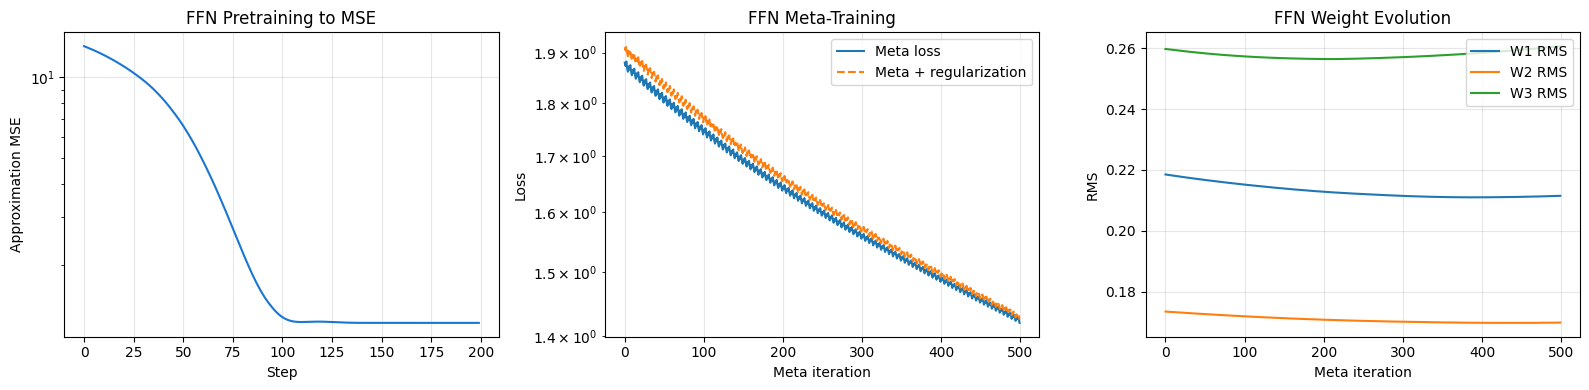

FFN 训练图已保存至 ./imgs/ffn_training.png


In [13]:
# ---- FFN 训练过程诊断 ----
fig_ffn, axes_ffn = plt.subplots(1, 3, figsize=(16, 4))

axes_ffn[0].plot(ffn_pretrain_history, color='#1976D2')
axes_ffn[0].set_yscale('log')
axes_ffn[0].set_title('FFN Pretraining to MSE')
axes_ffn[0].set_xlabel('Step')
axes_ffn[0].set_ylabel('Approximation MSE')
axes_ffn[0].grid(True, alpha=0.3)

axes_ffn[1].plot(meta_history_ffn['meta_loss'], label='Meta loss')
axes_ffn[1].plot(
    meta_history_ffn['total_loss'], '--', label='Meta + regularization'
)
axes_ffn[1].set_yscale('log')
axes_ffn[1].set_title('FFN Meta-Training')
axes_ffn[1].set_xlabel('Meta iteration')
axes_ffn[1].set_ylabel('Loss')
axes_ffn[1].legend()
axes_ffn[1].grid(True, alpha=0.3)

axes_ffn[2].plot(meta_history_ffn['w1_rms'], label='W1 RMS')
axes_ffn[2].plot(meta_history_ffn['w2_rms'], label='W2 RMS')
axes_ffn[2].plot(meta_history_ffn['w3_rms'], label='W3 RMS')
axes_ffn[2].set_title('FFN Weight Evolution')
axes_ffn[2].set_xlabel('Meta iteration')
axes_ffn[2].set_ylabel('RMS')
axes_ffn[2].legend()
axes_ffn[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./imgs/ffn_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("FFN 训练图已保存至 ./imgs/ffn_training.png")

## 9. 元测试：在新任务上验证

在元训练未见过的粘度系数 $\nu = 0.012/\pi$ 上，对比 LAL、FFN 两种元学习损失与 MSE、L1、Cauchy 三种基线。所有方法都使用相同网络结构并从头训练，最终统一使用 MSE 数据损失、MSE PDE 残差和相对 L2 误差进行评估。

In [14]:
# ---- 元测试训练辅助函数 ----
def train_pinn_with_lal(model, task, alpha_u, log_c_u, alpha_f, log_c_f,
                        learning_rate=1e-4, epochs=1000, verbose=True):
    """使用元训练得到的 LAL 参数从头训练一个 PINN。"""
    X_u = Tensor(task['X_u_train'], mstype.float32)
    U = Tensor(task['U_train'], mstype.float32)
    X_f = Tensor(task['X_f_train'], mstype.float32)
    nu = task['nu']

    alpha_u_t = Tensor(alpha_u, mstype.float32)
    log_c_u_t = Tensor(log_c_u, mstype.float32)
    alpha_f_t = Tensor(alpha_f, mstype.float32)
    log_c_f_t = Tensor(log_c_f, mstype.float32)
    optimizer = nn.Adam(model.trainable_params(), learning_rate=learning_rate)
    history = []

    for epoch in range(epochs):
        params = tuple(model.trainable_params())
        grads = _pinn_loss_grad(
            X_u, U, X_f, alpha_u_t, log_c_u_t,
            alpha_f_t, log_c_f_t, nu, *params
        )
        optimizer(grads)
        params = tuple(model.trainable_params())
        loss_val = compute_pinn_loss(
            X_u, U, X_f, alpha_u_t, log_c_u_t,
            alpha_f_t, log_c_f_t, nu, *params
        )
        history.append(float(loss_val.asnumpy()))
        if verbose and epoch % 200 == 0:
            print(f"  Epoch {epoch:4d}, Loss: {history[-1]:.6f}")
    return history


def compute_pinn_loss_mse(X_u, U, X_f, nu, *params):
    x_u, t_u = X_u[:, 0:1], X_u[:, 1:2]
    residual_data = net_u(x_u, t_u, *params) - U
    x_f, t_f = X_f[:, 0:1], X_f[:, 1:2]
    residual_pde = compute_pde_residual(x_f, t_f, nu, *params)
    return ops.reduce_mean(residual_data ** 2) + ops.reduce_mean(residual_pde ** 2)


def compute_pinn_loss_l1(X_u, U, X_f, nu, *params):
    x_u, t_u = X_u[:, 0:1], X_u[:, 1:2]
    residual_data = net_u(x_u, t_u, *params) - U
    x_f, t_f = X_f[:, 0:1], X_f[:, 1:2]
    residual_pde = compute_pde_residual(x_f, t_f, nu, *params)
    return ops.reduce_mean(ops.absolute(residual_data)) + ops.reduce_mean(ops.absolute(residual_pde))


def compute_pinn_loss_cauchy(X_u, U, X_f, nu, *params):
    x_u, t_u = X_u[:, 0:1], X_u[:, 1:2]
    residual_data = net_u(x_u, t_u, *params) - U
    x_f, t_f = X_f[:, 0:1], X_f[:, 1:2]
    residual_pde = compute_pde_residual(x_f, t_f, nu, *params)
    return ops.reduce_mean(ops.log1p(residual_data ** 2)) + ops.reduce_mean(ops.log1p(residual_pde ** 2))


_BASELINE_GRAD_POSITIONS = tuple(range(4, 4 + N_PARAMS))
_pinn_loss_mse_grad = ms.grad(compute_pinn_loss_mse, grad_position=_BASELINE_GRAD_POSITIONS)
_pinn_loss_l1_grad = ms.grad(compute_pinn_loss_l1, grad_position=_BASELINE_GRAD_POSITIONS)
_pinn_loss_cauchy_grad = ms.grad(compute_pinn_loss_cauchy, grad_position=_BASELINE_GRAD_POSITIONS)


def train_pinn_baseline(model, task, grad_fn, loss_fn,
                        learning_rate=1e-4, epochs=1000, verbose=True):
    """使用指定基线损失从头训练一个 PINN。"""
    X_u = Tensor(task['X_u_train'], mstype.float32)
    U = Tensor(task['U_train'], mstype.float32)
    X_f = Tensor(task['X_f_train'], mstype.float32)
    nu = task['nu']
    optimizer = nn.Adam(model.trainable_params(), learning_rate=learning_rate)
    history = []

    for epoch in range(epochs):
        params = tuple(model.trainable_params())
        grads = grad_fn(X_u, U, X_f, nu, *params)
        optimizer(grads)
        params = tuple(model.trainable_params())
        loss_val = loss_fn(X_u, U, X_f, nu, *params)
        history.append(float(loss_val.asnumpy()))
        if verbose and epoch % 200 == 0:
            print(f"  Epoch {epoch:4d}, Loss: {history[-1]:.6f}")
    return history

In [15]:
def evaluate_pinn(model, task):
    """评估 PINN 在任务全域上的 L2 相对误差和 MSE 损失分量（公平比较，统一用 MSE 评估）。"""
    X_star = Tensor(task['X_star'], mstype.float32)
    u_pred = model(X_star).asnumpy().flatten()
    u_exact = task['u_star'].flatten()

    l2_error = np.linalg.norm(u_exact - u_pred, 2) / np.linalg.norm(u_exact, 2)

    X_u = Tensor(task['X_u_train'], mstype.float32)
    U = Tensor(task['U_train'], mstype.float32)
    X_f = Tensor(task['X_f_train'], mstype.float32)
    nu = task['nu']

    x_u, t_u = X_u[:, 0:1], X_u[:, 1:2]
    u_pred_u = model(ops.concat((x_u, t_u), 1))
    loss_data = float(ops.reduce_mean((u_pred_u - U) ** 2).asnumpy())

    x_f, t_f = X_f[:, 0:1], X_f[:, 1:2]
    params = tuple(model.trainable_params())
    residual = compute_pde_residual(x_f, t_f, nu, *params)
    loss_pde = float(ops.reduce_mean(residual ** 2).asnumpy())

    return {
        'l2_error': l2_error,
        'loss_data': loss_data,
        'loss_pde': loss_pde,
        'u_pred': u_pred
    }


print("=" * 70)
print("元测试：对比 LAL、FFN 元学习 vs MSE、L1、Cauchy 基线")
print(f"测试任务: ν = {test_task['nu']:.6f}")
print("=" * 70)

results_all = {}
histories_all = {}

# ---- 方案A：LAL 元学习 ----
print("\n>>> 方案A: LAL 元学习损失")
alpha_u_final = float(alpha_u.asnumpy())
log_c_u_final = float(log_c_u.asnumpy())
alpha_f_final = float(alpha_f.asnumpy())
log_c_f_final = float(log_c_f.asnumpy())
c_u_final = float(ops.exp(log_c_u).asnumpy())
c_f_final = float(ops.exp(log_c_f).asnumpy())
print(f"参数: α_u={alpha_u_final:.4f}, c_u={c_u_final:.4f}, α_f={alpha_f_final:.4f}, c_f={c_f_final:.4f}")

model_lal = create_model()
history_lal = train_pinn_with_lal(
    model_lal, test_task, alpha_u_final, log_c_u_final,
    alpha_f_final, log_c_f_final, learning_rate=1e-4, epochs=1000
)
results_lal = evaluate_pinn(model_lal, test_task)
results_all['LAL (ours)'] = results_lal
histories_all['LAL (ours)'] = history_lal
print(f"结果: L2={results_lal['l2_error']:.6f}, MSE_data={results_lal['loss_data']:.6e}, MSE_pde={results_lal['loss_pde']:.6e}")

# ---- 方案B：FFN 元学习 ----
print("\n>>> 方案B: FFN 元学习损失")
model_ffn = create_model()
history_ffn = train_pinn_with_ffn(
    model_ffn, test_task, ffn_final_params,
    learning_rate=1e-4, epochs=1000
)
results_ffn = evaluate_pinn(model_ffn, test_task)
results_all['FFN (ours)'] = results_ffn
histories_all['FFN (ours)'] = history_ffn
print(f"结果: L2={results_ffn['l2_error']:.6f}, MSE_data={results_ffn['loss_data']:.6e}, MSE_pde={results_ffn['loss_pde']:.6e}")

# ---- 方案C：MSE 基线 ----
print("\n>>> 方案C: MSE 损失（传统 PINN）")
model_mse = create_model()
history_mse = train_pinn_baseline(
    model_mse, test_task, _pinn_loss_mse_grad, compute_pinn_loss_mse,
    learning_rate=1e-4, epochs=1000
)
results_mse = evaluate_pinn(model_mse, test_task)
results_all['MSE'] = results_mse
histories_all['MSE'] = history_mse
print(f"结果: L2={results_mse['l2_error']:.6f}, MSE_data={results_mse['loss_data']:.6e}, MSE_pde={results_mse['loss_pde']:.6e}")

# ---- 方案D：L1 基线 ----
print("\n>>> 方案D: L1 损失")
model_l1 = create_model()
history_l1 = train_pinn_baseline(
    model_l1, test_task, _pinn_loss_l1_grad, compute_pinn_loss_l1,
    learning_rate=1e-4, epochs=1000
)
results_l1 = evaluate_pinn(model_l1, test_task)
results_all['L1'] = results_l1
histories_all['L1'] = history_l1
print(f"结果: L2={results_l1['l2_error']:.6f}, MSE_data={results_l1['loss_data']:.6e}, MSE_pde={results_l1['loss_pde']:.6e}")

# ---- 方案E：Cauchy 基线 ----
print("\n>>> 方案E: Cauchy 损失")
model_cauchy = create_model()
history_cauchy = train_pinn_baseline(
    model_cauchy, test_task, _pinn_loss_cauchy_grad, compute_pinn_loss_cauchy,
    learning_rate=1e-4, epochs=1000
)
results_cauchy = evaluate_pinn(model_cauchy, test_task)
results_all['Cauchy'] = results_cauchy
histories_all['Cauchy'] = history_cauchy
print(f"结果: L2={results_cauchy['l2_error']:.6f}, MSE_data={results_cauchy['loss_data']:.6e}, MSE_pde={results_cauchy['loss_pde']:.6e}")

# ---- 汇总 ----
print("\n" + "=" * 70)
print("对比摘要:")
print(f"  {'方法':<15} {'L2相对误差':<14} {'数据损失(MSE)':<16} {'PDE损失(MSE)':<16}")
print(f"  {'-'*15} {'-'*14} {'-'*16} {'-'*16}")
for name, r in results_all.items():
    print(f"  {name:<15} {r['l2_error']:<14.6f} {r['loss_data']:<16.6e} {r['loss_pde']:<16.6e}")
print("=" * 70)

元测试：对比 LAL、FFN 元学习 vs MSE、L1、Cauchy 基线
测试任务: ν = 0.003820

>>> 方案A: LAL 元学习损失
参数: α_u=1.7741, c_u=1.4022, α_f=1.9841, c_f=1.4306


  Epoch    0, Loss: 0.064489


  Epoch  200, Loss: 0.052836


  Epoch  400, Loss: 0.039157


  Epoch  600, Loss: 0.034427


...

  Epoch  200, Loss: 0.171935


  Epoch  400, Loss: 0.130418


  Epoch  600, Loss: 0.147411


  Epoch  800, Loss: 0.117310


结果: L2=0.559567, MSE_data=5.502346e-02, MSE_pde=4.837213e-02

对比摘要:
  方法              L2相对误差         数据损失(MSE)        PDE损失(MSE)      
  --------------- -------------- ---------------- ----------------
  LAL (ours)      0.535873       4.628433e-02     7.751976e-02    
  FFN (ours)      0.993095       2.519489e-01     5.520397e-04    
  MSE             0.606110       5.929610e-02     6.126880e-02    
  L1              0.933597       2.206370e-01     3.171751e-04    
  Cauchy          0.559567       5.502346e-02     4.837213e-02    


## 10. 结果可视化

综合展示：元训练过程 + 测试任务上的解对比

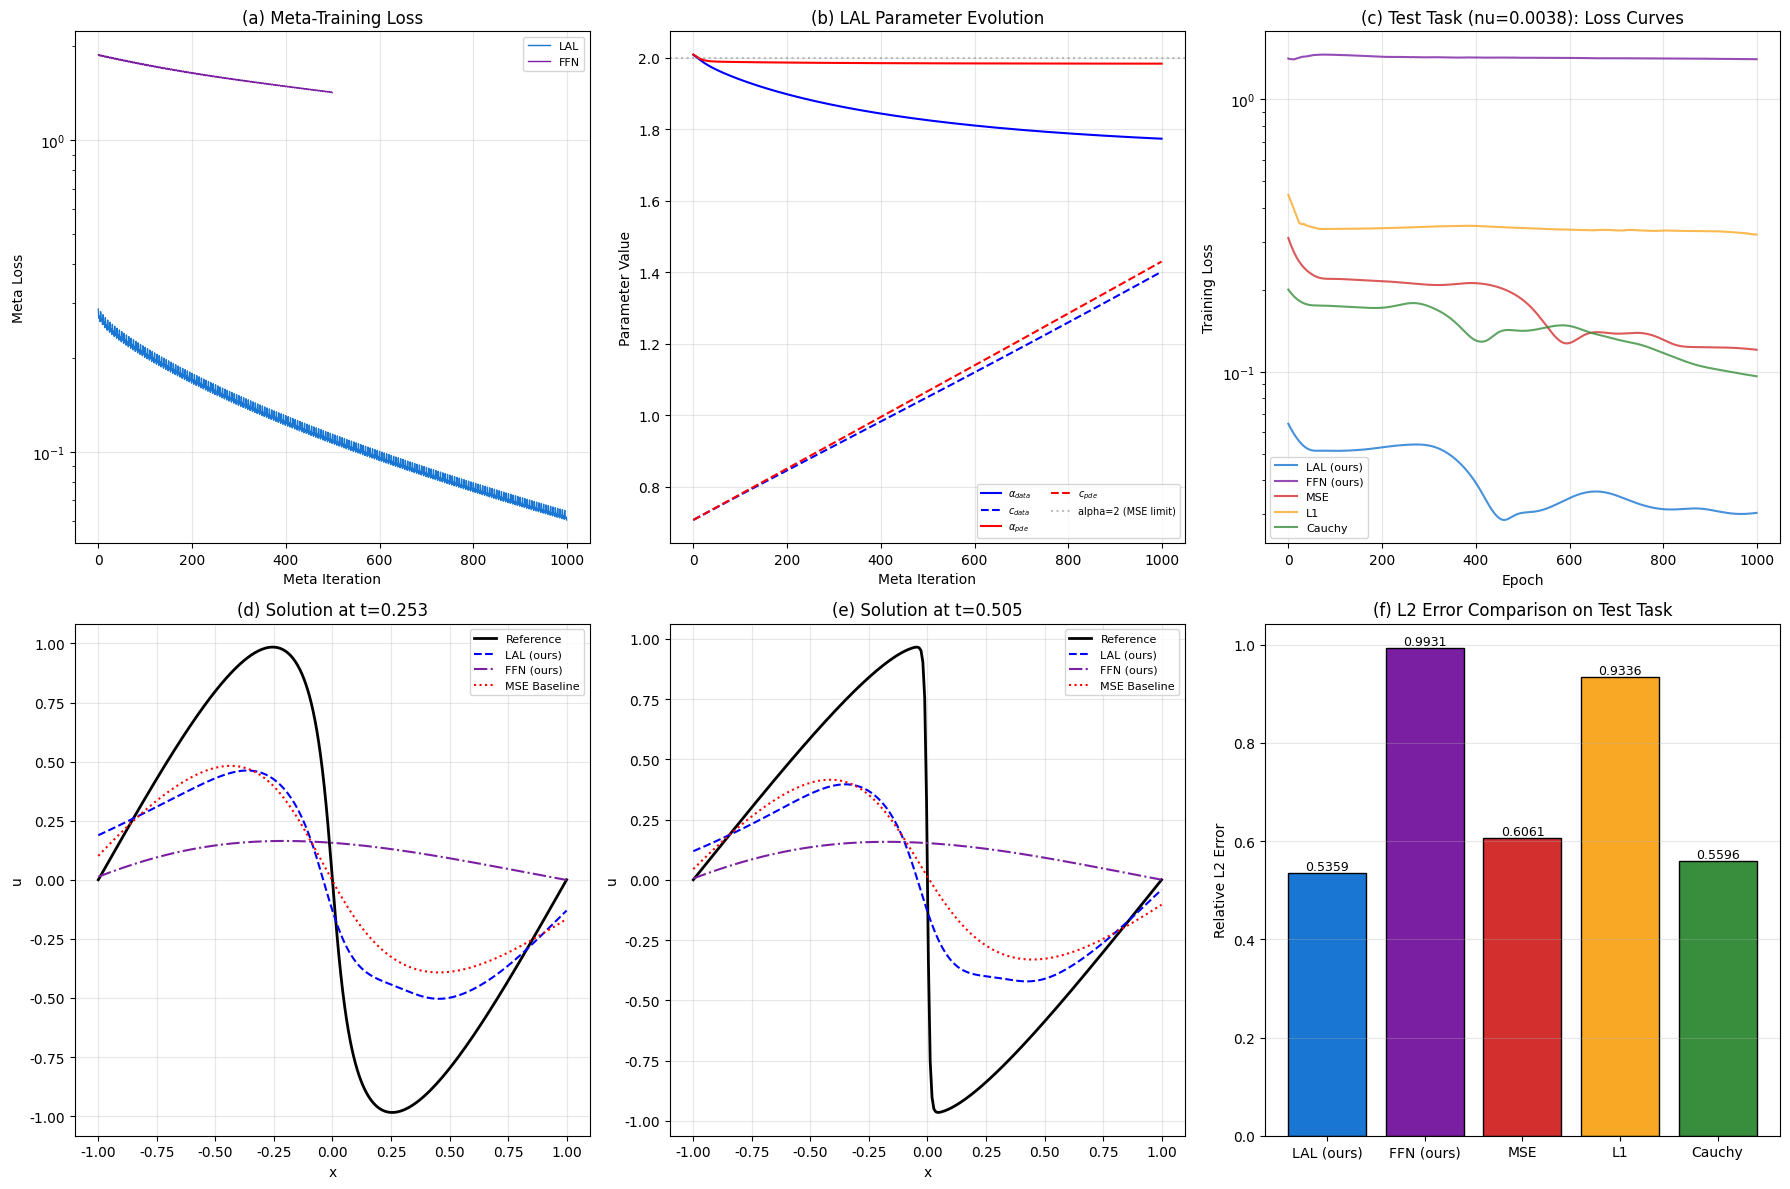


综合结果图已保存至 ./imgs/improved_result.png


In [16]:
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(18, 12))

# ---- (1) 元训练损失 ----
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(meta_history['meta_loss'], color='#1976D2', linewidth=1, label='LAL')
ax1.plot(meta_history_ffn['meta_loss'], color='#7B1FA2', linewidth=1, label='FFN')
ax1.legend(fontsize=8)
ax1.set_xlabel('Meta Iteration')
ax1.set_ylabel('Meta Loss')
ax1.set_title('(a) Meta-Training Loss')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# ---- (2) LAL 参数演化 ----
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(meta_history['alpha_u'], 'b-', label=r'$\alpha_{data}$', linewidth=1.5)
ax2.plot(meta_history['c_u'], 'b--', label=r'$c_{data}$', linewidth=1.5)
ax2.plot(meta_history['alpha_f'], 'r-', label=r'$\alpha_{pde}$', linewidth=1.5)
ax2.plot(meta_history['c_f'], 'r--', label=r'$c_{pde}$', linewidth=1.5)
ax2.axhline(y=2.0, color='gray', linestyle=':', alpha=0.5, label='alpha=2 (MSE limit)')
ax2.set_xlabel('Meta Iteration')
ax2.set_ylabel('Parameter Value')
ax2.set_title('(b) LAL Parameter Evolution')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

# ---- (3) 测试任务训练损失 ----
ax3 = fig.add_subplot(2, 3, 3)
colors_loss = {
    'LAL (ours)': '#1976D2', 'FFN (ours)': '#7B1FA2',
    'MSE': '#D32F2F', 'L1': '#F9A825', 'Cauchy': '#388E3C'
}
for name, history in histories_all.items():
    ax3.plot(history, color=colors_loss.get(name, 'gray'), label=name, linewidth=1.5, alpha=0.8)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Training Loss')
ax3.set_title(f'(c) Test Task (nu={test_task["nu"]:.4f}): Loss Curves')
ax3.set_yscale('log')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# 选择最接近目标时间的单个网格切片，避免把相邻时刻拼接在同一条曲线上。
X_star = test_task['X_star']
t_grid = np.unique(X_star[:, 1])

def get_time_slice(target_t):
    selected_t = t_grid[np.argmin(np.abs(t_grid - target_t))]
    mask = np.isclose(X_star[:, 1], selected_t)
    order = np.argsort(X_star[mask, 0])
    x_values = X_star[mask, 0][order]
    exact_values = test_task['u_star'][mask].flatten()[order]
    points = Tensor(X_star[mask][order], mstype.float32)
    return selected_t, x_values, exact_values, points

# ---- (4) t=0.25 时解对比 ----
ax4 = fig.add_subplot(2, 3, 4)
t_plot, x_plot, u_exact_plot, X_plot_tensor = get_time_slice(0.25)
u_lal_plot = model_lal(X_plot_tensor).asnumpy().flatten()
u_ffn_plot = model_ffn(X_plot_tensor).asnumpy().flatten()
u_mse_plot = model_mse(X_plot_tensor).asnumpy().flatten()
ax4.plot(x_plot, u_exact_plot, 'k-', label='Reference', linewidth=2)
ax4.plot(x_plot, u_lal_plot, 'b--', label='LAL (ours)', linewidth=1.5)
ax4.plot(x_plot, u_ffn_plot, color='#7B1FA2', linestyle='-.', label='FFN (ours)', linewidth=1.5)
ax4.plot(x_plot, u_mse_plot, 'r:', label='MSE Baseline', linewidth=1.5)
ax4.set_xlabel('x')
ax4.set_ylabel('u')
ax4.set_title(f'(d) Solution at t={t_plot:.3f}')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# ---- (5) t=0.5 时解对比 ----
ax5 = fig.add_subplot(2, 3, 5)
t_plot2, x_plot2, u_exact_plot2, X_plot_tensor2 = get_time_slice(0.5)
u_lal_plot2 = model_lal(X_plot_tensor2).asnumpy().flatten()
u_ffn_plot2 = model_ffn(X_plot_tensor2).asnumpy().flatten()
u_mse_plot2 = model_mse(X_plot_tensor2).asnumpy().flatten()
ax5.plot(x_plot2, u_exact_plot2, 'k-', label='Reference', linewidth=2)
ax5.plot(x_plot2, u_lal_plot2, 'b--', label='LAL (ours)', linewidth=1.5)
ax5.plot(x_plot2, u_ffn_plot2, color='#7B1FA2', linestyle='-.', label='FFN (ours)', linewidth=1.5)
ax5.plot(x_plot2, u_mse_plot2, 'r:', label='MSE Baseline', linewidth=1.5)
ax5.set_xlabel('x')
ax5.set_ylabel('u')
ax5.set_title(f'(e) Solution at t={t_plot2:.3f}')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# ---- (6) 相对 L2 误差 ----
ax6 = fig.add_subplot(2, 3, 6)
methods = list(results_all.keys())
l2_errors = [results_all[name]['l2_error'] for name in methods]
bar_colors = ['#1976D2', '#7B1FA2', '#D32F2F', '#F9A825', '#388E3C']
bars = ax6.bar(methods, l2_errors, color=bar_colors[:len(methods)], edgecolor='black', linewidth=1.0)
ax6.set_ylabel('Relative L2 Error')
ax6.set_title('(f) L2 Error Comparison on Test Task')
ax6.grid(True, alpha=0.3, axis='y')
for bar, error in zip(bars, l2_errors):
    ax6.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{error:.4f}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./imgs/improved_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n综合结果图已保存至 ./imgs/improved_result.png")